In [1]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.utils as utils
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import sys
import matplotlib.pyplot as plt
import numpy as np
import math
from torchvision.models import vgg16

In [ ]:
def visualize_filters(weights, layer_name):
    weights = weights.cpu().detach()
    if weights.shape[1] == 3:
        weights = weights
    else: # for layers with more than 3 channels, take only the first 3 channels
        weights = weights[:, :3, :, :] 
    f_min = weights.min()
    f_max = weights.max()
    weights = (weights - f_min) / (f_max - f_min)

    grid = utils.make_grid(weights, nrow=8, padding=1, normalize=False)
    np_grid = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(12, 12))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title(f'Filters of Layer: {layer_name}')
    plt.show()



In [11]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

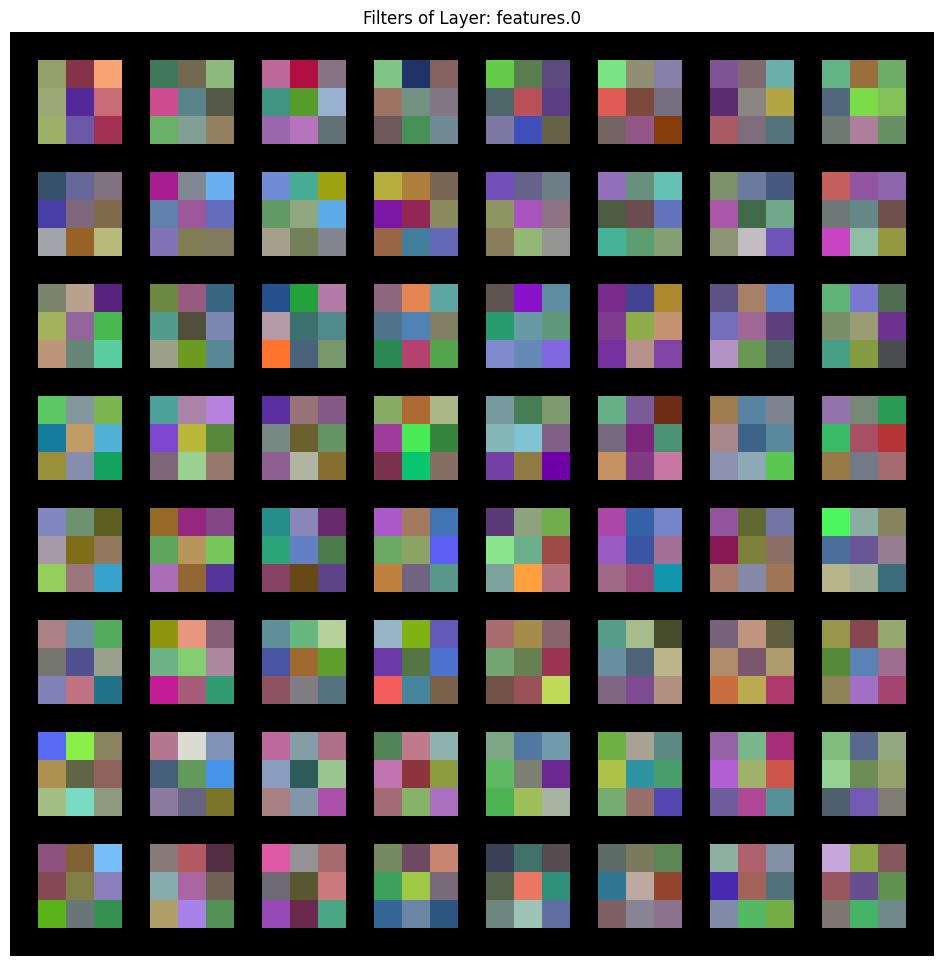

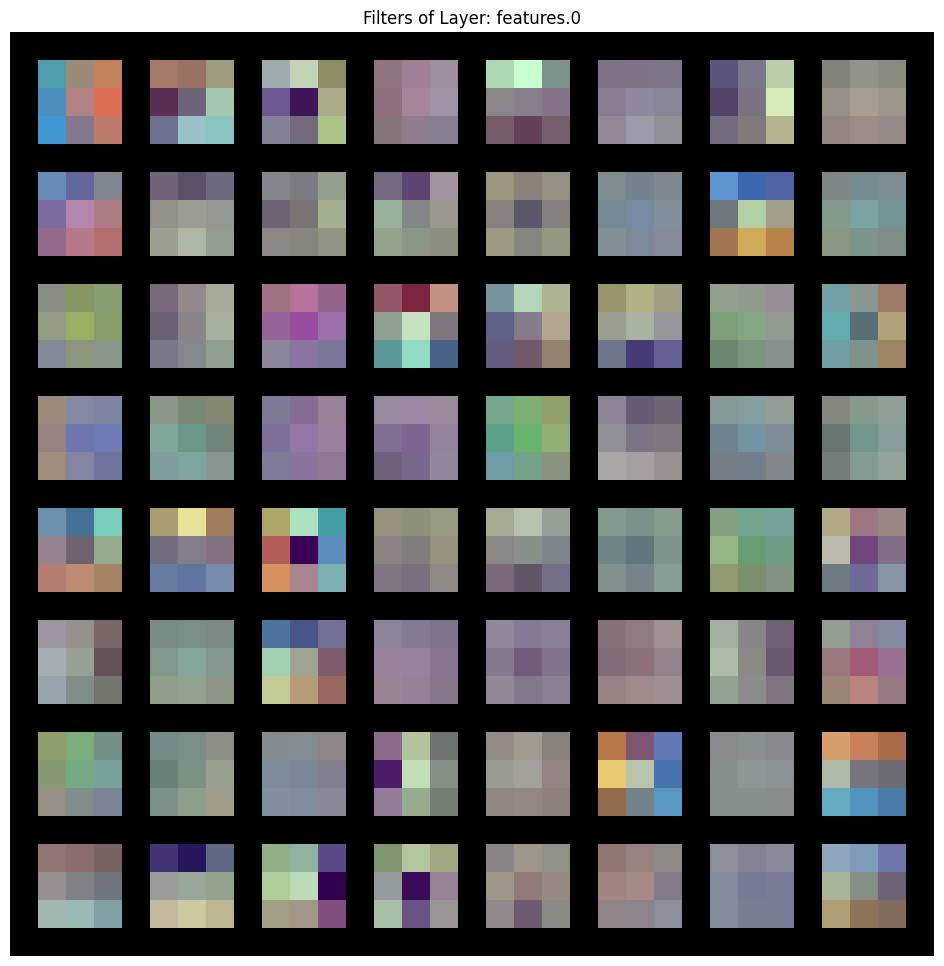

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [18]:

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

dataset1 = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataset2 = datasets.CIFAR10(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset1)
test_loader = torch.utils.data.DataLoader(dataset2)

model = models.vgg16()
visualize_filters(model.features[0].weight.data, 'features.0')

# # Visualize filters of all conv layers
# for name, module in model.named_modules():
#     if isinstance(module, nn.Conv2d):
#         weights = module.weight.data
#         print(f"\n Conv Layer: {name} | Shape: {weights.shape}")        
#         # if 'features.0' in name or 'features.2' in name or 'features.5' in name:
#         visualize_filters(weights, name)

model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
visualize_filters(model.features[0].weight.data, 'features.0')

num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 10)

model.eval() 


In [14]:
test(model, torch.device("cpu"), test_loader)


Test set: Average loss: 0.0715, Accuracy: 644/10000 (6%)




 Conv Layer: features.0 | Shape: torch.Size([64, 3, 3, 3])


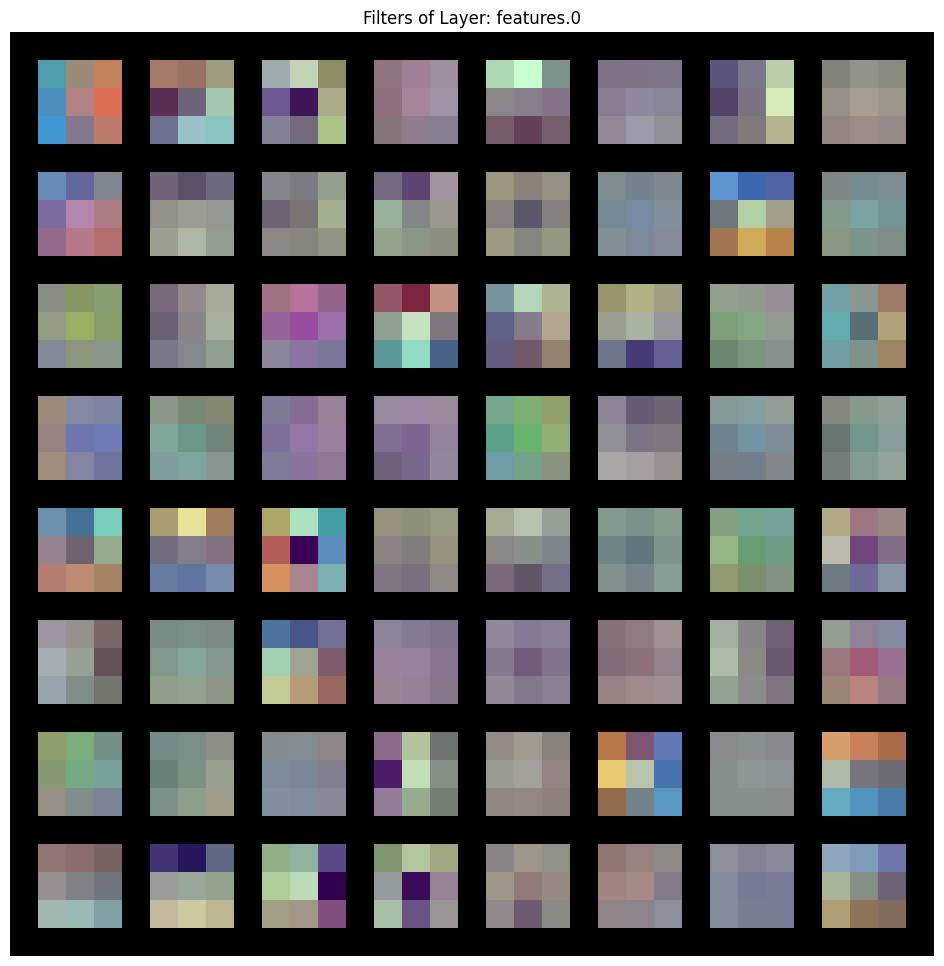


 Conv Layer: features.2 | Shape: torch.Size([64, 64, 3, 3])


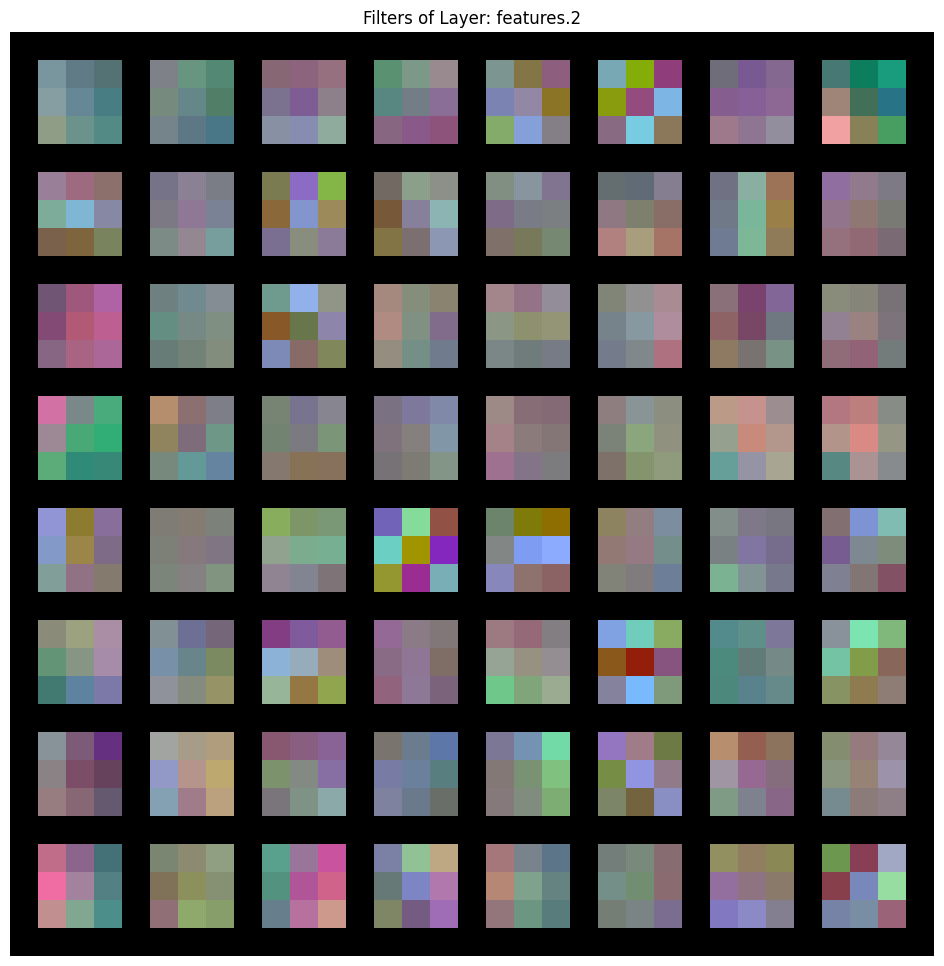


 Conv Layer: features.5 | Shape: torch.Size([128, 64, 3, 3])


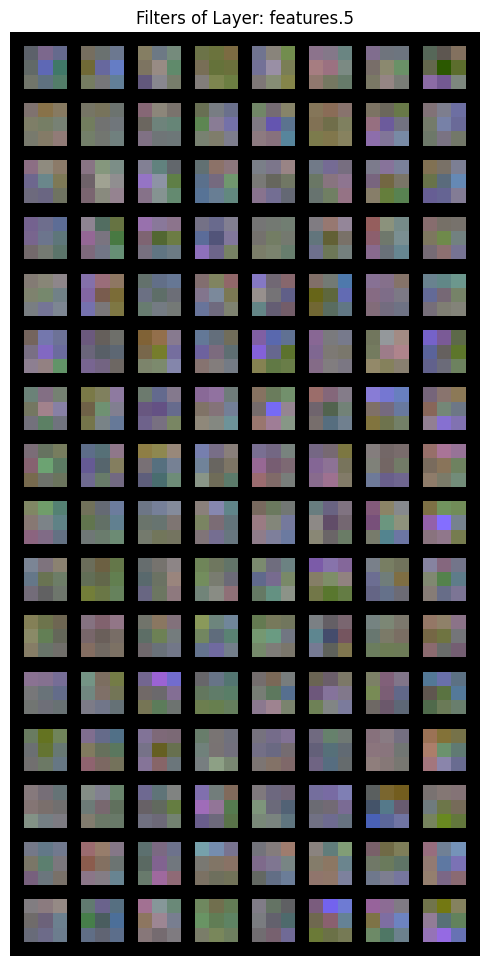


 Conv Layer: features.7 | Shape: torch.Size([128, 128, 3, 3])


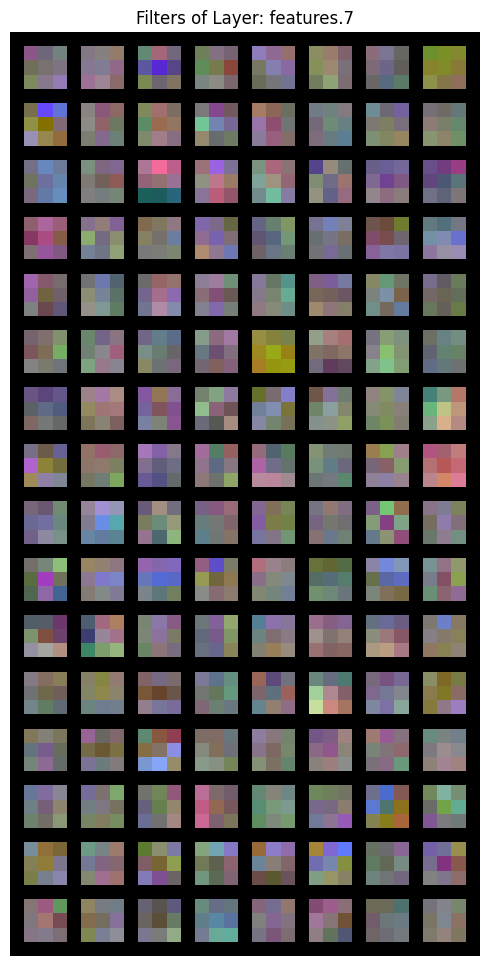


 Conv Layer: features.10 | Shape: torch.Size([256, 128, 3, 3])


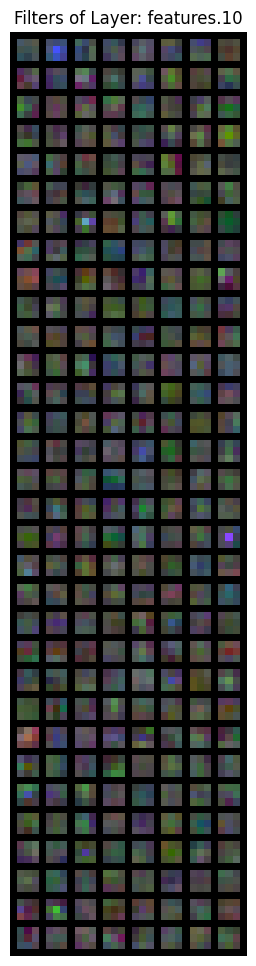


 Conv Layer: features.12 | Shape: torch.Size([256, 256, 3, 3])


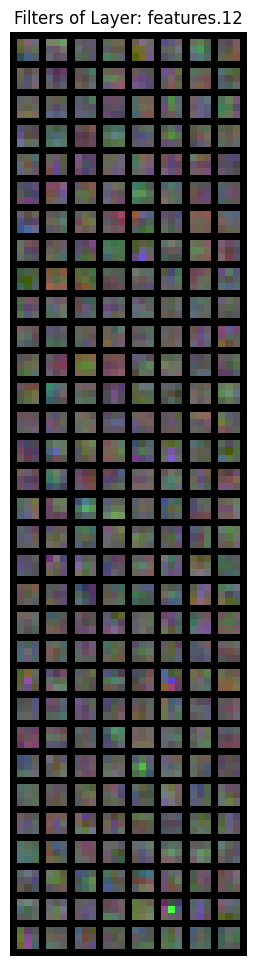


 Conv Layer: features.14 | Shape: torch.Size([256, 256, 3, 3])


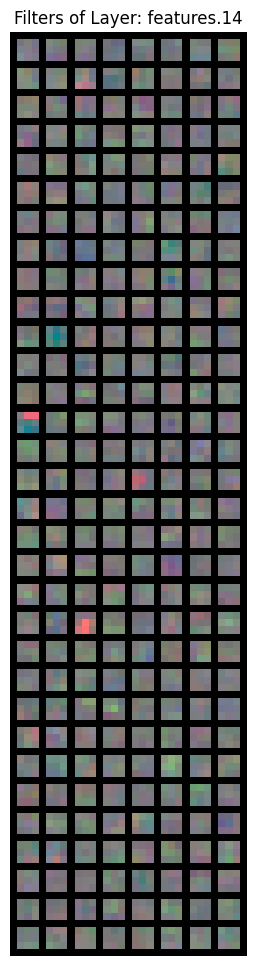


 Conv Layer: features.17 | Shape: torch.Size([512, 256, 3, 3])


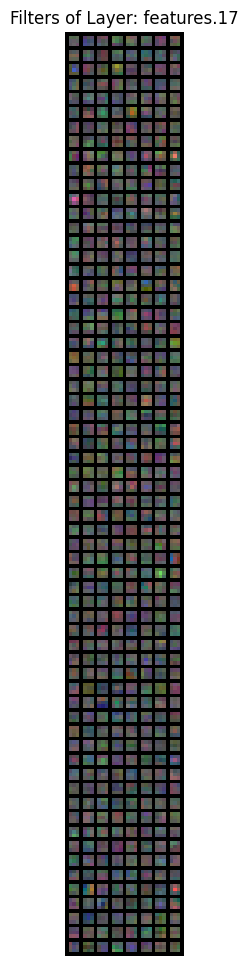


 Conv Layer: features.19 | Shape: torch.Size([512, 512, 3, 3])


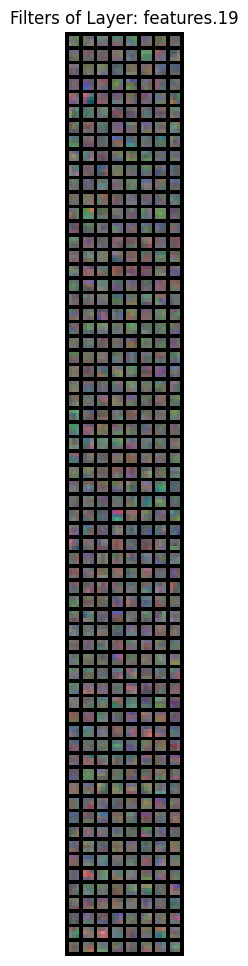


 Conv Layer: features.21 | Shape: torch.Size([512, 512, 3, 3])


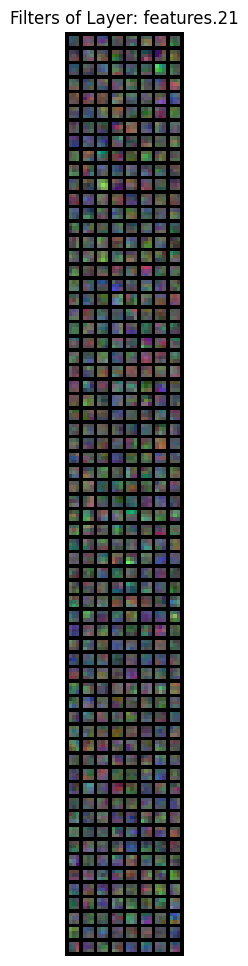


 Conv Layer: features.24 | Shape: torch.Size([512, 512, 3, 3])


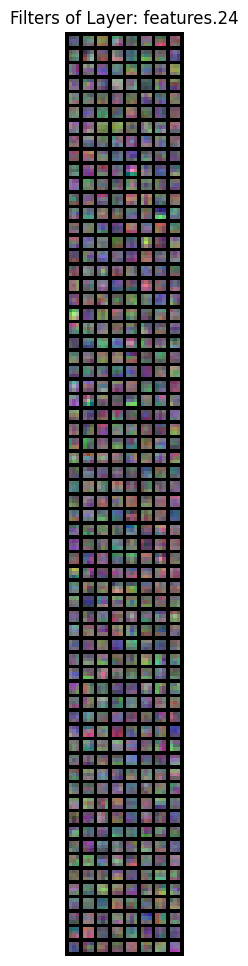


 Conv Layer: features.26 | Shape: torch.Size([512, 512, 3, 3])


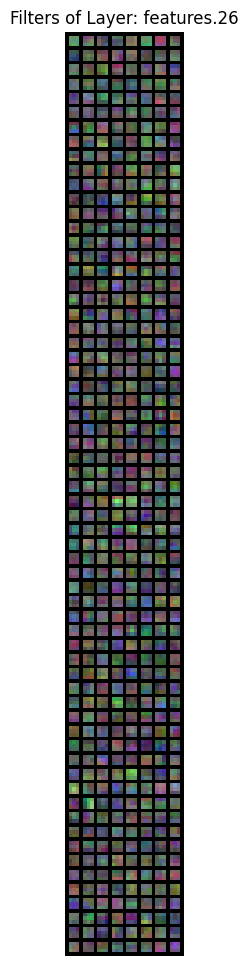


 Conv Layer: features.28 | Shape: torch.Size([512, 512, 3, 3])


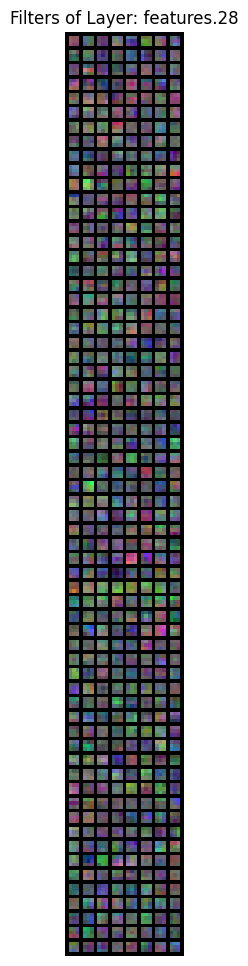

In [ ]:
# Visualize filters of all conv layers
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        weights = module.weight.data
        print(f"\n Conv Layer: {name} | Shape: {weights.shape}")        
        # if 'features.0' in name or 'features.2' in name or 'features.5' in name:
        visualize_filters(weights, name)


In [ ]:
# resnet18
from torchvision.models import resnet18

model = resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)

test(model, torch.device("cpu"), test_loader)


Test set: Average loss: 0.2748, Accuracy: 818/10000 (8%)

